In [51]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

In [52]:
BASE_DIR = r"C:\Users\Varun\OneDrive\Pictures\Desktop\waste_classification_project\application"
model_path = os.path.join(BASE_DIR, "models", "final_waste_model.keras")
test_dir   = os.path.join(BASE_DIR, "data", "split", "test")

In [80]:
# --- Load model ---
model = load_model(model_path)
print("✅ MobileNetV2 Model loaded successfully from:", model_path)

✅ MobileNetV2 Model loaded successfully from: C:\Users\Varun\OneDrive\Pictures\Desktop\waste_classification_project\application\models\final_waste_model.keras


In [54]:
# Image size (same as training) 
IMG_SIZE = (224, 224)

In [55]:
#Load class names 
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3498 images belonging to 10 classes.


In [56]:
class_indices = test_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Classes:", idx_to_class)

Classes: {0: 'battery', 1: 'cardboard waste', 2: 'clothe waste', 3: 'glass waste', 4: 'metal waste', 5: 'organic waste', 6: 'paper waste', 7: 'plastic waste', 8: 'shoes waste', 9: 'trash'}


In [57]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

c:\Users\Varun\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9651 - loss: 0.1169
Test Accuracy: 96.51%


In [58]:
#Predict on Entire Test Set
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
# True labels
y_true = test_generator.classes

110/110 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step


                 precision    recall  f1-score   support

        battery       1.00      0.99      0.99       284
cardboard waste       0.97      0.95      0.96       381
   clothe waste       0.98      1.00      0.99       375
    glass waste       0.97      0.94      0.95       413
    metal waste       0.95      0.98      0.97       307
  organic waste       0.99      0.96      0.98       336
    paper waste       0.92      0.97      0.94       417
  plastic waste       0.95      0.96      0.96       439
    shoes waste       0.99      0.98      0.98       298
          trash       0.95      0.93      0.94       248

       accuracy                           0.97      3498
      macro avg       0.97      0.97      0.97      3498
   weighted avg       0.97      0.97      0.97      3498



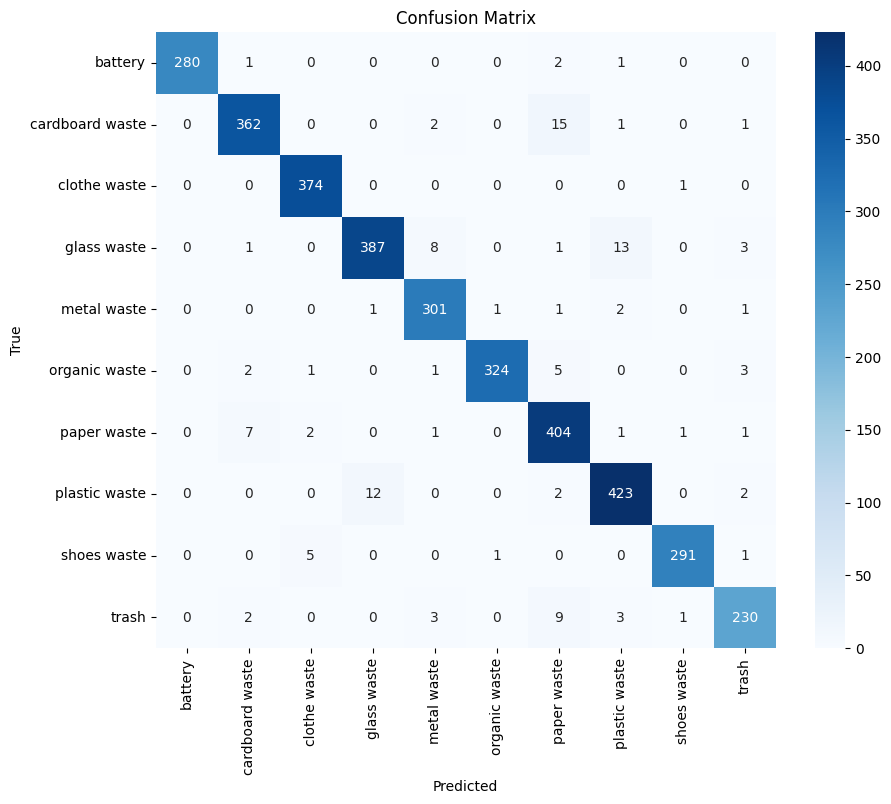

In [62]:
# Confusion Matrix & Report
print(classification_report(y_true, y_pred_classes, target_names=idx_to_class.values()))
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=idx_to_class.values(),
            yticklabels=idx_to_class.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### Randomly select one image from test folder Get all subfolders and files

🎯 Random image selected: C:\Users\Varun\OneDrive\Pictures\Desktop\waste_classification_project\application\data\split\test\trash\trash596.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Prediction: trash
confidence: 100.00%


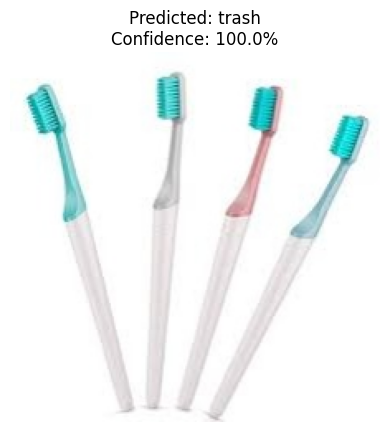

In [79]:
all_image_paths = []
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append(os.path.join(root, file))

random_image_path = random.choice(all_image_paths)
print("🎯 Random image selected:", random_image_path)

# Preprocess single image
img = load_img(random_image_path, target_size=IMG_SIZE)
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = idx_to_class[np.argmax(pred)]
confidence = np.max(pred) * 100
print(f"Prediction: {predicted_class}")
print(f"confidence: {confidence:.2f}%")

# Plot the selected image
plt.imshow(load_img(random_image_path))
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.1f}%")
plt.axis("off")
plt.show()